<a href="https://colab.research.google.com/github/Liping-LZ/BDAO_DSDO/blob/main/Week%202/BDAO_Block3_Analysis_Student_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BDAO Block 3 — Retail Data Analysis
### Festive & Co. · From Data to Business Insights

**This is the reference notebook shared after the session.**
It contains the two complete sample analysis including worked interpretations and insights.

| Symbol | Meaning |
|---|---|
| 📖 | Read and understand |
| ▶️ | Run this cell |
| ✏️ | Adapt for your own analysis |
| 🤖 | Use AI to help generate code |

**Structure:**
1. Setup + authenticate
2. Run the pipeline (skip if already done in Block 2)
3. Load data + create working DataFrames
4. Seasonal analysis — finding, insight, recommendation
5. Customer analysis — EDA + modelling + interpretation


---
## ▶️ Step 1 — Install, authenticate and configure

In [ ]:
!pip install google-cloud-storage google-cloud-bigquery pandas-gbq ucimlrepo --quiet
print('Done.')

Done.


In [ ]:
from google.colab import auth
auth.authenticate_user()
print('Authenticated.')

Authenticated.


In [ ]:
# ── FILL IN YOUR DETAILS ──────────────────────────────
project_id   = 'your-project-id'    # ← replace
bucket_name  = 'your-bucket-name'   # ← replace
dataset_name = 'your-dataset-name'  # ← replace
# ──────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from datetime import datetime
from google.cloud import storage, bigquery
from ucimlrepo import fetch_ucirepo

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 15)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

storage_client  = storage.Client(project=project_id)
bigquery_client = bigquery.Client(project=project_id)

def run_query(sql):
    """Run SQL on BigQuery and return a DataFrame."""
    return bigquery_client.query(sql).to_dataframe()

def load_to_bq(df, table_name):
    """Save a DataFrame to BigQuery."""
    df_bq = df.copy()
    for col in df_bq.select_dtypes(include=['datetime64']).columns:
        df_bq[col] = df_bq[col].astype(str)
    df_bq.to_gbq(f'{dataset_name}.{table_name}',
                 project_id=project_id, if_exists='replace', progress_bar=False)
    print(f'  Saved: {project_id}.{dataset_name}.{table_name} ({len(df_bq):,} rows)')

print(f'Connected: {project_id}')

Connected: bdao-dsdo-458210


---
## ▶️ Step 2 — Run the pipeline

📖 **If you completed Block 2:** your data is already in BigQuery. Skip to Step 3.

📖 **If you did not complete Block 2:** run the cell below. It fetches the UCI retail data, cleans it, and loads it to BigQuery automatically. This is the full pipeline from Block 2 — same code, one function call.

⏱ Takes approximately 3-5 minutes to run.

In [ ]:
def run_pipeline():
    """
    Full ELT pipeline — UCI retail data to BigQuery.
    Same pipeline built in Block 2.
    Stages: Extract → Load raw to GCS → Validate → Transform → Load to BigQuery
    """
    t0 = datetime.now()
    print(f'Pipeline started: {t0.strftime("%H:%M:%S")}')
    print('=' * 50)

    # Stage 1: Extract
    print('[1/5] Extracting from UCI...')
    dataset = fetch_ucirepo(id=352)
    raw = pd.concat([dataset.data.ids, dataset.data.features], axis=1).copy()
    print(f'      {len(raw):,} rows fetched')

    # Stage 2: Load raw to GCS
    print('[2/5] Saving raw file to Cloud Storage...')
    bucket = storage_client.bucket(bucket_name)
    blob   = bucket.blob('online_retail_raw.json')
    blob.upload_from_string(raw.to_json(orient='records', lines=True))
    print(f'      gs://{bucket_name}/online_retail_raw.json')

    # Stage 3: Validate
    print('[3/5] Validating...')
    print(f'      Missing: {raw.isnull().sum().sum():,} | Dupes: {raw.duplicated().sum():,}')

    # Stage 4: Transform
    print('[4/5] Transforming...')
    df = raw.copy()
    df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')
    df['Quantity']    = pd.to_numeric(df['Quantity'],  errors='coerce')
    df['UnitPrice']   = pd.to_numeric(df['UnitPrice'], errors='coerce')
    df['InvoiceNo']   = df['InvoiceNo'].astype(str).str.strip()
    df['StockCode']   = df['StockCode'].astype(str).str.strip().str.upper()
    df['Description'] = df['Description'].astype(str).str.strip().str.title()
    df['Country']     = df['Country'].astype(str).str.strip().str.title()
    df['CustomerID']  = df['CustomerID'].astype(str).str.replace(r'\.0$','',regex=True)
    df = df.drop_duplicates().dropna(subset=['InvoiceDate'])
    df['is_cancellation'] = df['InvoiceNo'].str.startswith('C')
    df['is_return']       = df['Quantity'] < 0
    df['is_zero_price']   = df['UnitPrice'] <= 0
    df['is_guest']        = df['CustomerID'] == 'nan'
    df['Revenue']    = df['Quantity'] * df['UnitPrice']
    df['MonthLabel'] = df['InvoiceDate'].dt.strftime('%Y-%m')
    df['Year']       = df['InvoiceDate'].dt.year
    df['Month']      = df['InvoiceDate'].dt.month
    df['DayOfWeek']  = df['InvoiceDate'].dt.day_name()
    df['Hour']       = df['InvoiceDate'].dt.hour
    df = df[[
        'InvoiceNo','InvoiceDate','MonthLabel','Year','Month','DayOfWeek','Hour',
        'StockCode','Description','Quantity','UnitPrice','Revenue',
        'CustomerID','Country',
        'is_cancellation','is_return','is_zero_price','is_guest'
    ]]
    print(f'      {len(raw):,} → {len(df):,} rows')

    # Stage 5: Load to BigQuery
    print('[5/5] Loading to BigQuery...')
    dataset_ref = bigquery.DatasetReference(project_id, dataset_name)
    dataset_obj = bigquery.Dataset(dataset_ref)
    dataset_obj.location = 'EU'
    try:
        bigquery_client.get_dataset(dataset_ref)
    except Exception:
        bigquery_client.create_dataset(dataset_obj, timeout=30)
    load_to_bq(df, 'retail_transactions')

    secs = (datetime.now() - t0).seconds
    print('=' * 50)
    print(f'Pipeline complete in {secs}s')
    print(f'Table: {project_id}.{dataset_name}.retail_transactions')


# ── RUN OR SKIP ───────────────────────────────────────────────────────────
# If you already ran this in Block 2, skip this cell and go to Step 3
# If you need to run it now, uncomment the line below:

# run_pipeline()

---
## ▶️ Step 3 — Load data and create working DataFrames

📖 We load the full clean transactions table from BigQuery and split it into four focused DataFrames. Each one is filtered for a specific type of analysis so you do not have to repeat filters in every cell.

Run all cells in this step before starting your analysis.

In [ ]:
# Load the full clean transactions table from BigQuery
print('Loading retail_transactions from BigQuery...')

df = run_query(f"""
    SELECT *
    FROM `{project_id}.{dataset_name}.retail_transactions`
""")

# Parse date
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

print(f'Loaded: {len(df):,} rows, {df.shape[1]} columns')
df.head()

Loading retail_transactions from BigQuery...
Loaded: 536,641 rows, 19 columns


,InvoiceNo,InvoiceDate,MonthLabel,Year,Month,DayOfWeek,Hour,...,CustomerID,Country,is_cancellation,is_guest,is_return,is_zero_price,negative_price
0,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
1,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
2,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
3,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
4,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False


In [ ]:
# ── WORKING DATAFRAMES ────────────────────────────────────────────────────

# df_sales — clean regular sales only
# Use for: revenue analysis, product analysis, country analysis, trends
df_sales = df[
    (~df['is_cancellation']) &
    (~df['is_return'])       &
    (~df['is_zero_price'])   &
    (df['Quantity'] > 0)
].copy()

# df_cancellations — cancelled orders only
# Use for: understanding cancellation patterns — when, where, which products
df_cancellations = df[df['is_cancellation']].copy()

# df_returns — returned items only
# Use for: understanding return patterns — which products, which countries
df_returns = df[df['is_return'] & ~df['is_cancellation']].copy()

# df_customers — clean sales from known customers only (no guest checkouts)
# Use for: customer-level analysis — loyalty, frequency, spend
df_customers = df_sales[~df_sales['is_guest']].copy()

print('Working DataFrames ready:')
print(f'  df_sales:          {len(df_sales):,} rows — clean regular sales')
print(f'  df_cancellations:  {len(df_cancellations):,} rows — cancelled orders')
print(f'  df_returns:        {len(df_returns):,} rows — returned items')
print(f'  df_customers:      {len(df_customers):,} rows — sales with known customer, guest checkouts excluded')

Working DataFrames ready:
  df_sales:          524,880 rows — clean regular sales
  df_cancellations:  9,251 rows — cancelled orders
  df_returns:        1,336 rows — returned items
  df_customers:      392,692 rows — sales with known customer, guest checkouts excluded


In [ ]:
# Quick overview of what we are working with
print('=== FESTIVE & CO. DATA OVERVIEW ===')
print(f'Period:           {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')
print(f'Total orders:     {df_sales["InvoiceNo"].nunique():,}')
print(f'Known customers:  {df_customers["CustomerID"].nunique():,}')
print(f'Products:         {df_sales["StockCode"].nunique():,}')
print(f'Countries:        {df_sales["Country"].nunique()}')
print(f'Total revenue:    £{df_sales["Revenue"].sum():,.0f}')
print(f'Cancellation rate:{df_cancellations["InvoiceNo"].nunique()/df["InvoiceNo"].nunique()*100:.1f}%')
print()
df_sales.head(3)

=== FESTIVE & CO. DATA OVERVIEW ===
Period:           2010-12-01 to 2011-12-09
Total orders:     19,962
Known customers:  4,338
Products:         3,812
Countries:        38
Total revenue:    £10,619,987
Cancellation rate:14.8%



,InvoiceNo,InvoiceDate,MonthLabel,Year,Month,DayOfWeek,Hour,...,CustomerID,Country,is_cancellation,is_guest,is_return,is_zero_price,negative_price
0,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
1,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False
2,536365,2010-12-01 08:26:00,2010-12,2010,12,Wednesday,8,...,17850,United Kingdom,False,False,False,False,False


---
## 📖 Step 4 — Seasonal Analysis

**Business question:** How does Festive & Co.'s revenue behave across the year — and what does this mean for business strategy?

This connects directly to Sarah's concern: *'Every January feels like a disaster. I do not know if it is normal or something we did wrong.'*

📖 **Data limitation to note first:**
The dataset runs from 1 Dec 2010 to 9 Dec 2011. This means:
- **December 2010** — only 1 month at the very start of the data
- **December 2011** — only 9 days of data (the dataset cuts off on 9 Dec)
- **Full months available:** January 2011 through November 2011 — 11 complete months

Any interpretation involving December must acknowledge this limitation.

In [ ]:
# Step 4.1 — Monthly revenue, orders and average order value
monthly = (
    df_sales
    .groupby('MonthLabel')
    .agg(
        orders          = ('InvoiceNo',  'nunique'),
        customers       = ('CustomerID', 'nunique'),
        total_revenue   = ('Revenue',    'sum'),
        avg_order_value = ('Revenue',    'mean')
    )
    .round(2)
    .reset_index()
)

print('Monthly summary:')
monthly

Monthly summary:


,MonthLabel,orders,customers,total_revenue,avg_order_value
0,2010-12,1559,886,821452.73,20.04
1,2011-01,1086,742,689811.61,20.25
2,2011-02,1100,759,522545.56,19.44
3,2011-03,1454,975,716215.26,20.18
4,2011-04,1246,857,536968.49,18.59
5,2011-05,1681,1057,769296.61,21.42
6,2011-06,1533,992,760547.01,21.29
7,2011-07,1475,950,718076.12,18.70
8,2011-08,1363,936,735717.26,21.47
9,2011-09,1837,1267,1056435.19,21.60


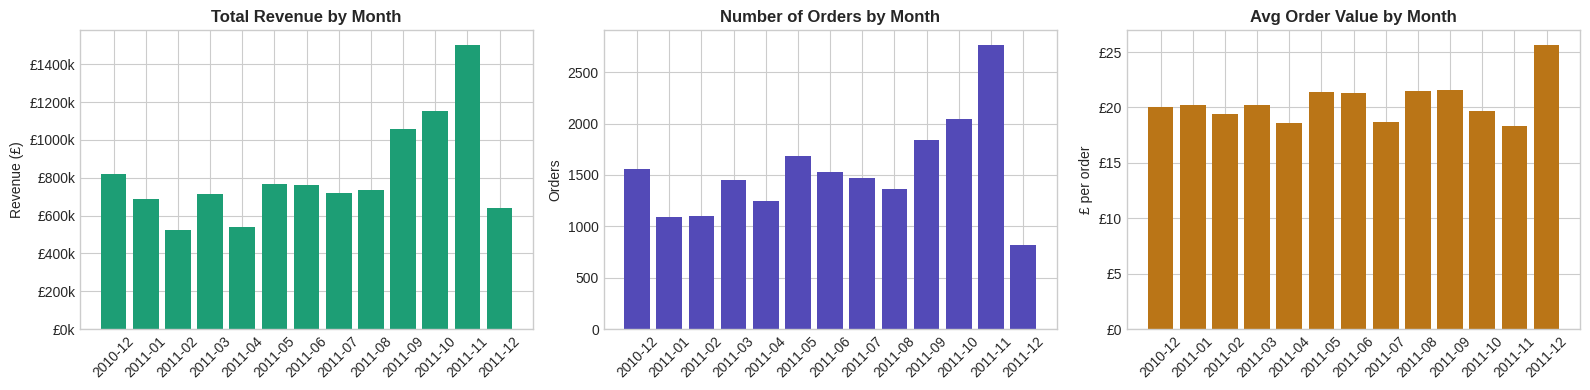

In [ ]:
# Step 4.2 — Visualise the pattern
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Revenue
axes[0].bar(monthly['MonthLabel'], monthly['total_revenue'], color='#1D9E75')
axes[0].set_title('Total Revenue by Month', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))

# Orders
axes[1].bar(monthly['MonthLabel'], monthly['orders'], color='#534AB7')
axes[1].set_title('Number of Orders by Month', fontweight='bold')
axes[1].set_ylabel('Orders')
axes[1].tick_params(axis='x', rotation=45)

# Average order value
axes[2].bar(monthly['MonthLabel'], monthly['avg_order_value'], color='#BA7517')
axes[2].set_title('Avg Order Value by Month', fontweight='bold')
axes[2].set_ylabel('£ per order')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}'))

plt.tight_layout()
plt.show()

Quarterly summary:
  InvoiceDate  orders  customers  total_revenue  avg_order_value
0      2010Q4    1559        886      821452.73            20.04
1      2011Q1    3640       1777     1928572.43            20.00
2      2011Q2    4460       1992     2066812.11            20.56
3      2011Q3    4675       2162     2510228.57            20.65
4      2011Q4    5628       2561     3292920.84            19.91


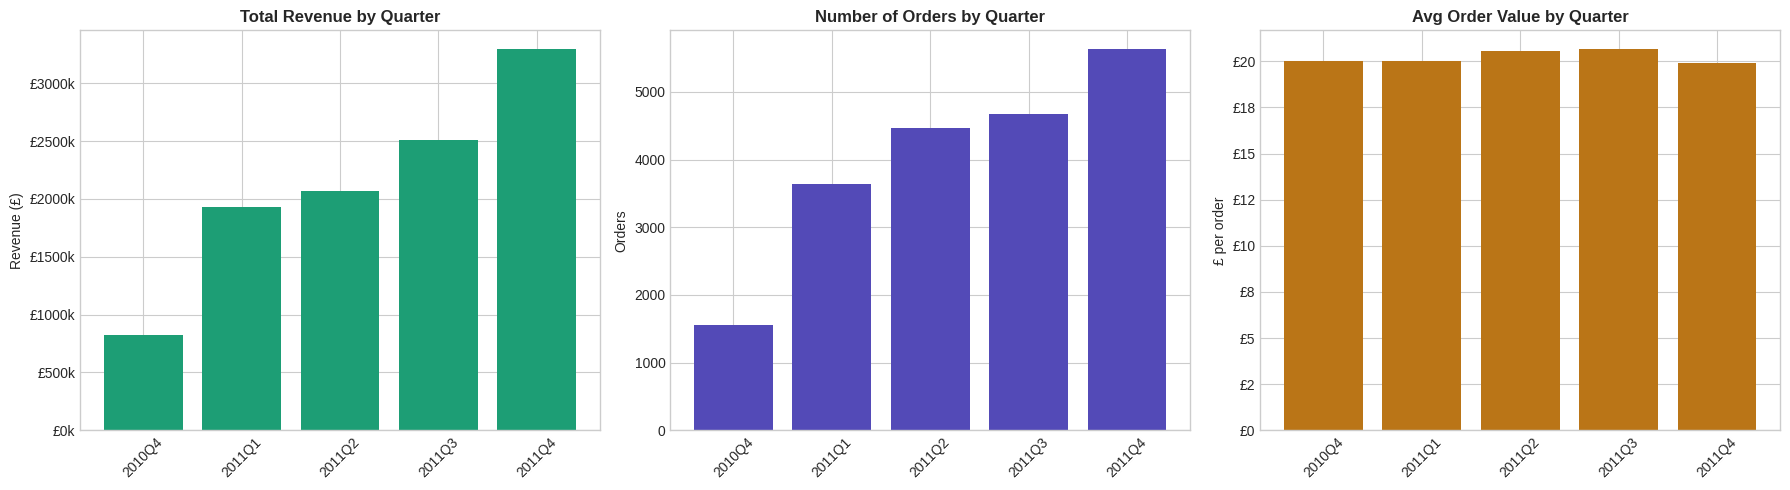

In [ ]:
# Step 4.3 - Plot revenue, orders, and average order value by quarter

# Aggregate data by quarter
quarterly = (
    df_sales
    .groupby(df_sales['InvoiceDate'].dt.to_period('Q'))
    .agg(
        orders          = ('InvoiceNo',  'nunique'),
        customers       = ('CustomerID', 'nunique'),
        total_revenue   = ('Revenue',    'sum'),
        avg_order_value = ('Revenue',    'mean')
    )
    .round(2)
    .reset_index()
)
# Convert Quarter to string for plotting
quarterly['InvoiceDate'] = quarterly['InvoiceDate'].astype(str)

print('Quarterly summary:')
print(quarterly)

# Plotting the quarterly patterns
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Revenue
axes[0].bar(quarterly['InvoiceDate'], quarterly['total_revenue'], color='#1D9E75')
axes[0].set_title('Total Revenue by Quarter', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))

# Orders
axes[1].bar(quarterly['InvoiceDate'], quarterly['orders'], color='#534AB7')
axes[1].set_title('Number of Orders by Quarter', fontweight='bold')
axes[1].set_ylabel('Orders')
axes[1].tick_params(axis='x', rotation=45)

# Average order value
axes[2].bar(quarterly['InvoiceDate'], quarterly['avg_order_value'], color='#BA7517')
axes[2].set_title('Avg Order Value by Quarter', fontweight='bold')
axes[2].set_ylabel('£ per order')
axes[2].tick_params(axis='x', rotation=45)
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}'))

plt.tight_layout()
plt.show()

Daily summary for 2011:
          Day  orders  customers  total_revenue  avg_order_value
0  2011-01-04      36         35       16005.73            13.95
1  2011-01-05      55         46       32630.27            19.61
2  2011-01-06      50         46       40366.45            22.91
3  2011-01-07      53         46       28836.59            16.33
4  2011-01-09      48         48       15590.68            14.52


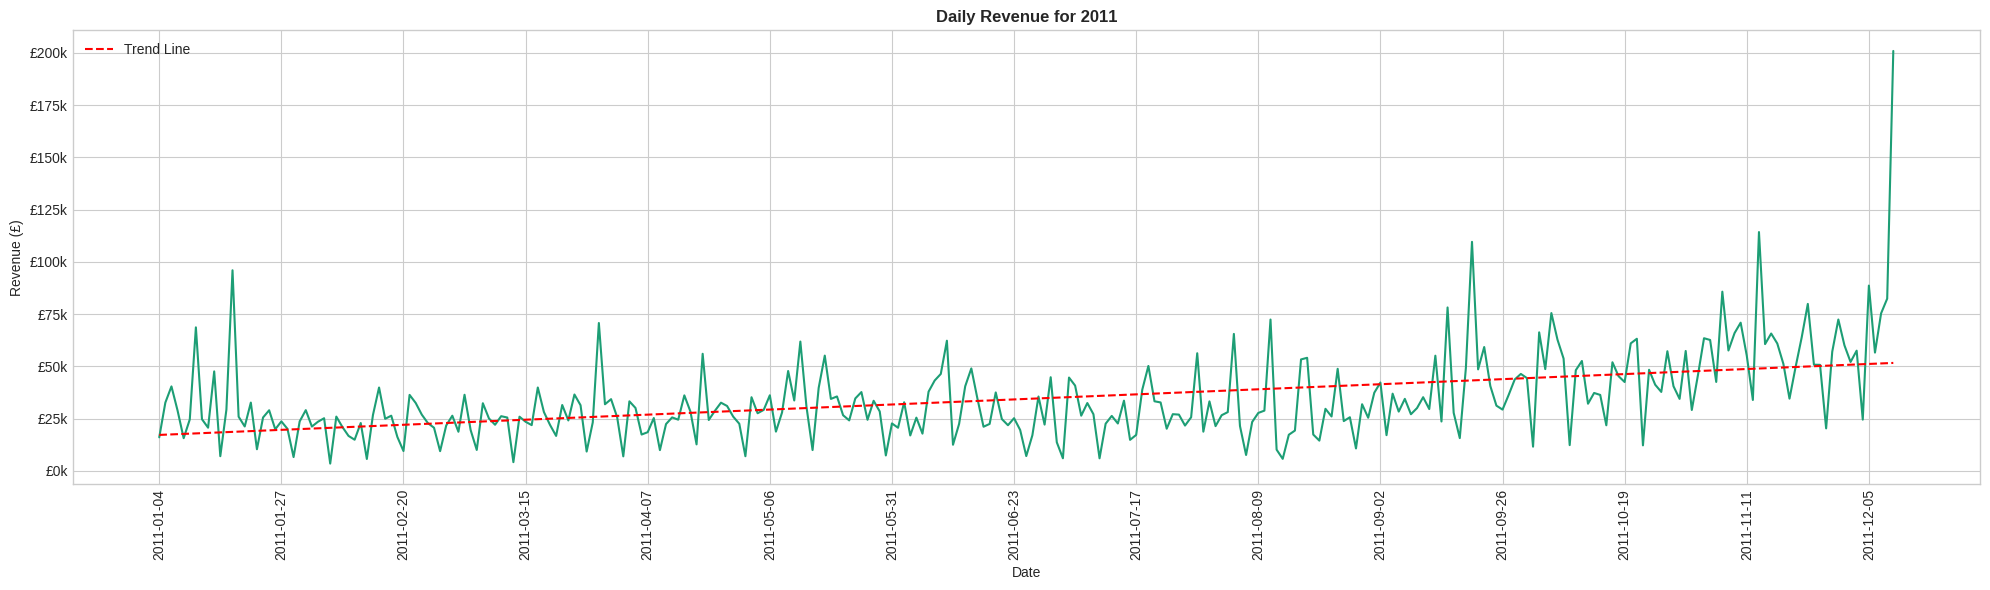

In [ ]:
# Step 4.4 - Plot the daily revenue
daily_2011 = (
    df_sales[
        (df_sales['InvoiceDate'] >= '2011-01-01') &
        (df_sales['InvoiceDate'] < '2012-01-01')
    ]
    .groupby(df_sales['InvoiceDate'].dt.date)
    .agg(
        orders          = ('InvoiceNo',  'nunique'),
        customers       = ('CustomerID', 'nunique'),
        total_revenue   = ('Revenue',    'sum'),
        avg_order_value = ('Revenue',    'mean')
    )
    .round(2)
    .reset_index()
)
daily_2011 = daily_2011.rename(columns={'InvoiceDate': 'Day'})

print('Daily summary for 2011:')
print(daily_2011.head())

fig, ax = plt.subplots(figsize=(20, 6))

ax.plot(daily_2011['Day'].astype(str), daily_2011['total_revenue'], color='#1D9E75')
ax.set_title('Daily Revenue for 2011', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue (£)')
ax.tick_params(axis='x', rotation=90)
ax.xaxis.set_major_locator(plt.MaxNLocator(20))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x/1000:.0f}k'))

# Add trend line
x_numeric = np.arange(len(daily_2011))
slope, intercept = np.polyfit(x_numeric, daily_2011['total_revenue'], 1)
trend_line = slope * x_numeric + intercept
ax.plot(daily_2011['Day'].astype(str), trend_line, color='red', linestyle='--', label='Trend Line')
ax.legend()

plt.tight_layout()
plt.show()

### 📖 From data to insight: Seasonal revenue

---

#### Finding

Revenue and order volume follow a clear and consistent seasonal pattern. The monthly chart shows Q4 (October–November) generating the highest revenue of the year — November 2011 alone reaches £1.47 million, more than double the February low of £0.58 million. Crucially, the **average order value remains almost flat** across all months, hovering between £18–£26. The quarterly chart confirms the trend: each quarter outperforms the last, with 2011Q4 generating £3.3 million.

*Note: 2010Q4 contains only December 2010 and 2011Q4 runs to 9 December only — both are incomplete. True Q4 2011 revenue would be higher.*

---

#### What the data is telling us — and what it is not

The growth in revenue is driven entirely by **volume** (more orders), not by customers spending more per transaction. Average order value is flat at ~£20 across all quarters. This is a critical distinction:

> **The seasonal peak is a demand surge, not a change in customer spending behaviour.**

This means Sarah cannot grow off-peak revenue by encouraging customers to spend more per visit — they are already spending consistently. The problem is that they simply do not visit outside the gift-giving calendar.

---

#### Insight

Festive & Co. is **structurally dependent on Q4 demand**. The revenue gap between peak and trough is a frequency problem, not a spend problem. This creates significant business risk — a poor Q4 due to supply chain disruption, a failed campaign, or an economic downturn reducing discretionary spending cannot be compensated for by the rest of the year.

---

#### Recommendation

To grow off-peak revenue, Festive & Co. needs to create reasons to buy that are independent of the existing holiday calendar.

**1. Build a themed gifting calendar for non-peak months.**
February has Valentine's Day but the data shows it as the lowest revenue month — suggesting Festive & Co. is not capturing this occasion effectively. Other opportunities: Mother's Day (March/May), Father's Day (June), back-to-school gifting (August/September). Each occasion needs a dedicated product bundle and a targeted campaign, not just a generic promotion.

**2. Launch a subscription gifting programme.**
The flat average order value suggests customers buy what they need and stop — there is no upsell happening. A quarterly gift box subscription converts a one-time seasonal buyer into a predictable revenue stream. Even converting 5% of existing customers would meaningfully smooth the revenue curve.

**3. Target corporate gifting for Q2 and Q3.**
Corporate clients buy gifts year-round — for employee recognition, client appreciation, and event gifting — and they tend to order in larger quantities. A B2B gifting proposition targeting SMEs would access demand entirely independent of the consumer holiday calendar.

---
## 📖 Step 5 — Customer Analysis

**Business question:** Who are Festive & Co.'s most valuable customers — and what distinguishes repeat buyers from one-time buyers?

This connects to Sarah's concern: *'I think some customers come back every Christmas but I have no idea how many of them there are or how to reach them.'*

We work through four analytical lenses:
1. Order frequency distribution — how many orders do customers typically place?
2. Revenue contribution — do repeat customers generate disproportionately more revenue?
3. Geographic distribution — where are repeat customers concentrated?
4. Recency and activity — are some loyal customers going inactive?

Then we use a machine learning model to confirm and deepen the patterns we find.

In [ ]:
# Step 1 — Build a customer value summary
customer_summary = (
    df_customers
    .groupby('CustomerID')
    .agg(
        country         = ('Country',     'first'),
        total_orders    = ('InvoiceNo',   'nunique'),
        total_spend     = ('Revenue',     'sum'),
        avg_order_value = ('Revenue',     'mean'),
        first_purchase  = ('InvoiceDate', 'min'),
        last_purchase   = ('InvoiceDate', 'max')
    )
    .round(2)
    .reset_index()
    .sort_values('total_spend', ascending=False)
)

# Days between first and last purchase (loyalty proxy)
customer_summary['days_active'] = (
    customer_summary['last_purchase'] - customer_summary['first_purchase']
).dt.days

customer_summary['days_since_last'] = (
    pd.to_datetime('2011-12-10') - customer_summary['last_purchase']
).dt.days

customer_summary['days_since_first'] = (
    pd.to_datetime('2011-12-10') - customer_summary['first_purchase']).dt.days

print(f'Total known customers: {len(customer_summary):,}')
print()
print('Top 10 customers by total spend:')
customer_summary.head(10)

Total known customers: 4,338

Top 10 customers by total spend:


,CustomerID,country,total_orders,total_spend,avg_order_value,first_purchase,last_purchase,days_active,days_since_last,days_since_first
1689,14646,Netherlands,73,280206.02,134.97,2010-12-20 10:09:00,2011-12-08 12:12:00,353,1,354
4201,18102,United Kingdom,60,259657.30,602.45,2010-12-07 16:42:00,2011-12-09 11:50:00,366,0,367
3728,17450,United Kingdom,46,194390.79,578.54,2010-12-07 09:23:00,2011-12-01 13:29:00,359,8,367
3008,16446,United Kingdom,2,168472.50,56157.50,2011-05-18 09:52:00,2011-12-09 09:15:00,204,0,205
1879,14911,Eire,201,143711.17,25.35,2010-12-01 14:05:00,2011-12-08 15:54:00,372,1,373
55,12415,Australia,21,124914.53,174.95,2011-01-06 11:12:00,2011-11-15 14:22:00,313,24,337
1333,14156,Eire,55,117210.08,84.02,2010-12-03 11:48:00,2011-11-30 10:54:00,361,9,371
3771,17511,United Kingdom,31,91062.38,94.56,2010-12-01 10:19:00,2011-12-07 10:12:00,370,2,373
2702,16029,United Kingdom,63,80850.84,335.48,2010-12-01 09:57:00,2011-11-01 10:27:00,335,38,373
0,12346,United Kingdom,1,77183.60,77183.60,2011-01-18 10:01:00,2011-01-18 10:01:00,0,325,325


### 5.1 — Order frequency distribution

How many orders do customers typically place? This tells us whether the customer base is predominantly one-time buyers or whether a meaningful repeat segment exists.

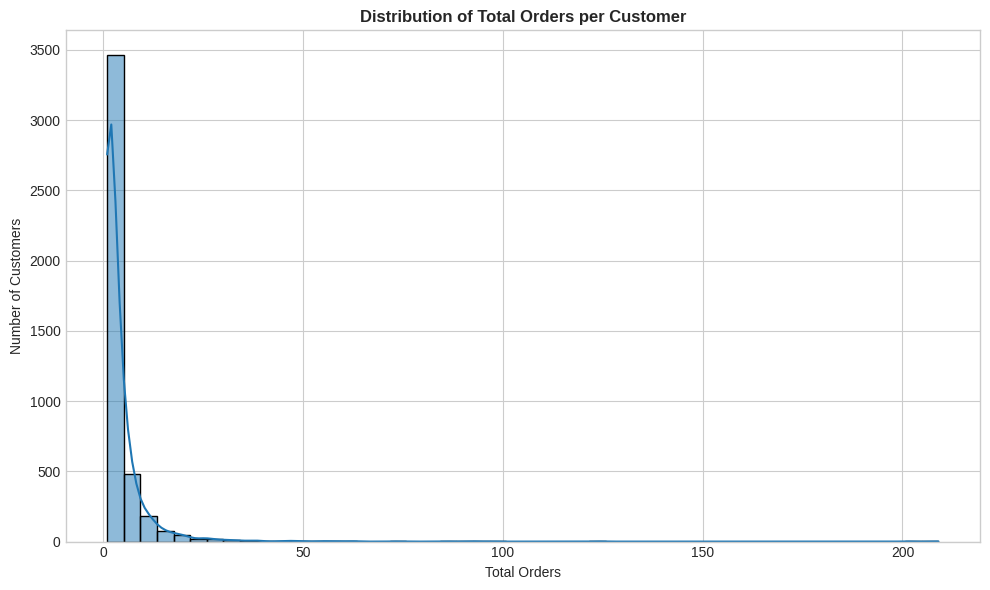

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
order_dist = sns.histplot(
    data=customer_summary,
    x='total_orders',
    bins=50, # Adjust bin size for better distribution visibility
    kde=True # Add a kernel density estimate for a smooth curve
)
order_dist.set_title('Distribution of Total Orders per Customer', fontweight='bold')
order_dist.set_xlabel('Total Orders')
order_dist.set_ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [ ]:
customer_summary['repeat_flag'] = customer_summary['total_orders'].apply(lambda x: 'Repeat' if x > 1 else 'One-time')
print(customer_summary['repeat_flag'].value_counts())

repeat_flag
Repeat (2+ orders)    2845
One-time (1 order)    1493
Name: count, dtype: int64


#### 📖 Interpretation

The distribution is strongly right-skewed — the vast majority of customers place only 1 or 2 orders, while a small tail places many more. This is a classic pattern in e-commerce and is sometimes called the **long tail of customer loyalty**.

The practical implication: most customers who ever buy from Festive & Co. buy once and never return. A small group of highly engaged customers orders repeatedly. These two groups need to be treated completely differently — the one-time group needs conversion, the repeat group needs protection.

### 5.2 — Revenue contribution: one-time vs repeat customers

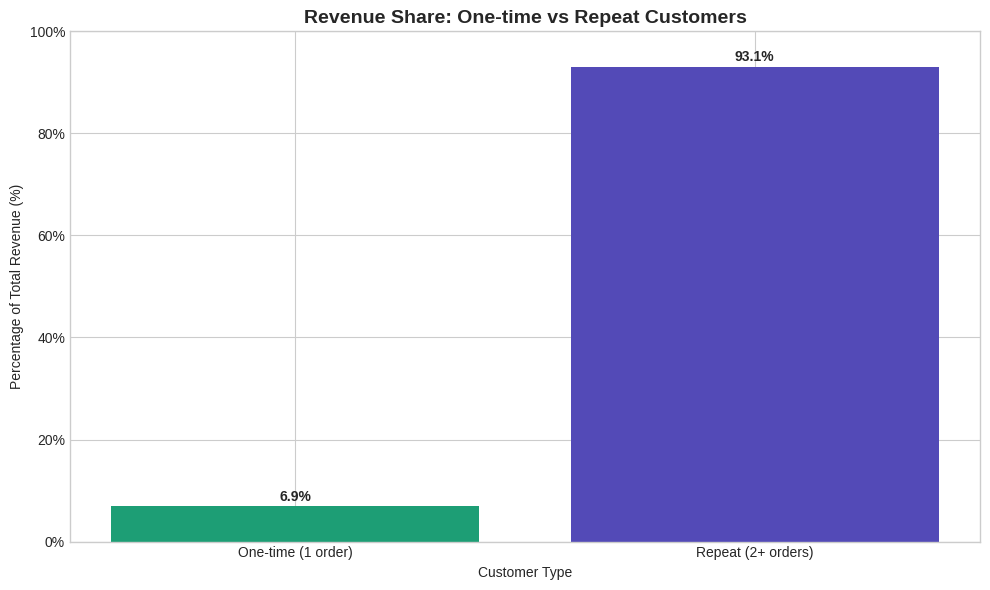

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Explicitly create the 'compare' DataFrame
compare = customer_summary.groupby('repeat_flag').agg(
    customers=('CustomerID','count'),
    total_revenue=('total_spend','sum'),
    avg_order_value=('avg_order_value','mean') # Add AOV calculation
).reset_index()

compare.columns = ['type','customers','total_revenue', 'avg_order_value']
compare['revenue_share'] = (compare['total_revenue'] / compare['total_revenue'].sum() * 100).round(2)


fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(compare['type'], compare['revenue_share'], color=['#1D9E75', '#534AB7'])
ax.set_title('Revenue Share: One-time vs Repeat Customers', fontweight='bold', fontsize=14)
ax.set_xlabel('Customer Type')
ax.set_ylabel('Percentage of Total Revenue (%)')

# Add percentage labels on top of the bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_ylim(0, 100) # Ensure y-axis goes up to 100%
ax.yaxis.set_major_formatter(mticker.PercentFormatter())

plt.tight_layout()
plt.show()

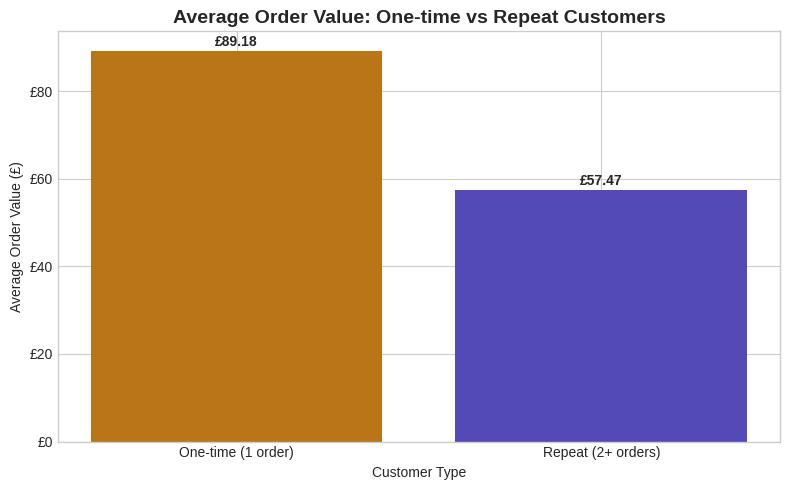

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(compare['type'], compare['avg_order_value'], color=['#BA7517', '#534AB7'])
ax.set_title('Average Order Value: One-time vs Repeat Customers', fontweight='bold', fontsize=14)
ax.set_xlabel('Customer Type')
ax.set_ylabel('Average Order Value (£)')

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'£{yval:.2f}', ha='center', va='bottom', fontweight='bold')

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'£{x:.0f}'))
plt.tight_layout()
plt.show()

#### 📖 Interpretation

Two things stand out from this comparison:

**Customer split:** Repeat customers outnumber one-time customers in this dataset. This is a healthier position than typical e-commerce benchmarks — it suggests Festive & Co. has a genuine returning customer base, likely reinforced by the seasonal gifting nature of the product. Customers who buy as a Christmas gift one year tend to return the next.

**Revenue share:** Repeat customers generate a larger share of total revenue than one-time customers. Given that they outnumber one-time buyers and place more orders, this is the expected outcome — not a surprise finding. The more meaningful number to examine is the revenue contribution *per customer* in each group, which reflects the difference in order frequency rather than any concentration effect.

**Average order value:** The average order value is similar between one-time and repeat customers. Repeat customers are not spending more per transaction — they are simply transacting more often. The value of a repeat customer comes from **frequency**, not from larger individual purchases.

> **Business implication:** The relatively strong repeat customer base is an asset Sarah may not fully appreciate. The strategic priority is not to acquire new customers at all costs — it is to protect and reactivate the existing repeat base, and to understand what converts a one-time buyer into a repeat buyer.

### 5.3 — Customer recency and activity

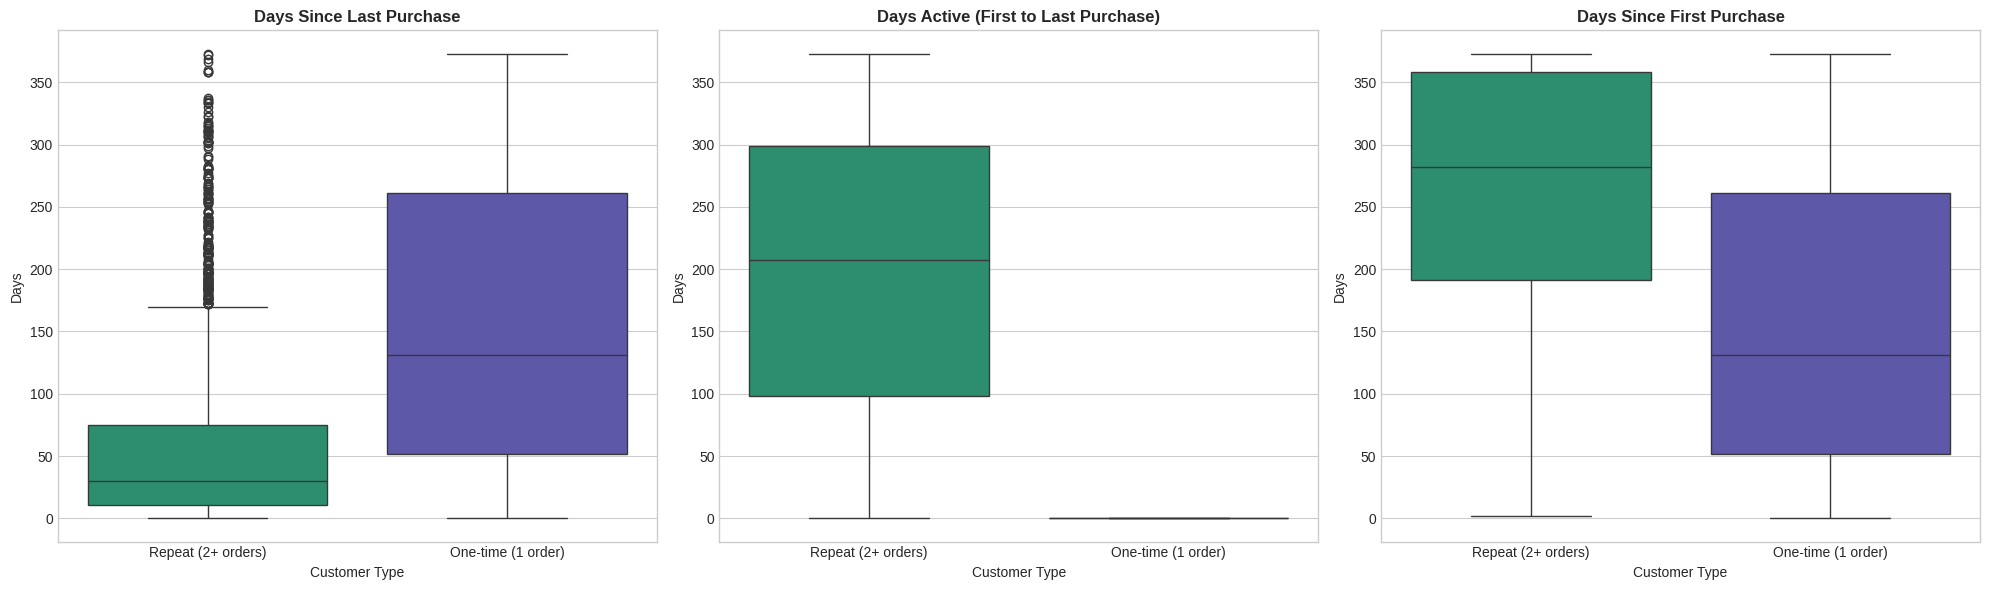

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Days Since Last Purchase
sns.boxplot(x='repeat_flag', y='days_since_last', data=customer_summary, ax=axes[0], palette=['#1D9E75', '#534AB7'])
axes[0].set_title('Days Since Last Purchase', fontweight='bold')
axes[0].set_xlabel('Customer Type')
axes[0].set_ylabel('Days')

# Days Active (Loyalty Proxy)
sns.boxplot(x='repeat_flag', y='days_active', data=customer_summary, ax=axes[1], palette=['#1D9E75', '#534AB7'])
axes[1].set_title('Days Active (First to Last Purchase)', fontweight='bold')
axes[1].set_xlabel('Customer Type')
axes[1].set_ylabel('Days')

# Days Since First Purchase
sns.boxplot(x='repeat_flag', y='days_since_first', data=customer_summary, ax=axes[2], palette=['#1D9E75', '#534AB7'])
axes[2].set_title('Days Since First Purchase', fontweight='bold')
axes[2].set_xlabel('Customer Type')
axes[2].set_ylabel('Days')

plt.tight_layout()
plt.show()

In [ ]:
# Filter for repeat customers with days since last purchase > 150 days
inactive_repeat_customers = customer_summary[
    (customer_summary['repeat_flag'] == 'Repeat') &
    (customer_summary['days_since_last'] > 150)
].copy()

print(f"Number of repeat customers with no purchase in over 150 days: {len(inactive_repeat_customers):,}")
print("These are repeat customers who are potentially churning or have churned.")
inactive_repeat_customers.head()

Number of repeat customers with no purchase in over 150 days: 343
These are repeat customers who are potentially churning or have churned.


,CustomerID,country,total_orders,total_spend,avg_order_value,first_purchase,last_purchase,days_active,days_since_last,days_since_first,repeat_flag
2502,15749,United Kingdom,3,44534.30,4453.43,2011-01-11 12:55:00,2011-04-18 13:20:00,97,235,332,Repeat (2+ orders)
2011,15098,United Kingdom,3,39916.50,13305.50,2011-06-10 15:22:00,2011-06-10 15:33:00,0,182,182,Repeat (2+ orders)
196,12590,Germany,2,9864.26,145.06,2011-05-12 14:46:00,2011-05-12 14:52:00,0,211,211,Repeat (2+ orders)
566,13093,United Kingdom,8,7832.47,49.26,2010-12-01 15:00:00,2011-03-09 12:14:00,97,275,373,Repeat (2+ orders)
485,12980,United Kingdom,9,7374.90,368.74,2010-12-16 11:36:00,2011-07-05 09:34:00,200,157,358,Repeat (2+ orders)


#### 📖 Interpretation

The recency charts reveal something concerning: a subset of customers who have purchased multiple times have not bought anything in over 150 days. These are **at-risk loyal customers** — they have demonstrated they like the product enough to return, but they appear to be going dormant.

This group deserves specific attention because:
- They are proven buyers — not prospects who might not convert
- They have a demonstrated purchase history that tells us what they buy
- A targeted reactivation campaign can reach them with a personalised offer

> **Business implication:** Do not wait for loyal customers to lapse entirely. A 'we miss you' campaign to customers who have not ordered in 90+ days — timed to arrive before a gift-giving occasion — is one of the highest-ROI marketing activities available to Festive & Co.

### 5.4 — RFM segmentation

RFM (Recency, Frequency, Monetary value) combines three dimensions into a single customer score. Customers who bought recently, buy often, and spend the most are the most valuable. This gives Sarah a prioritised list rather than a flat customer database.

In [ ]:
# --- RFM SCORING FOR CUSTOMERS ---

# 1. Define Recency, Frequency, Monetary values
#    - Recency: days since last purchase (lower is better)
#    - Frequency: total number of orders (higher is better)
#    - Monetary: total spend (higher is better)

# We already have these columns in customer_summary:
#   'days_since_last' (Recency)
#   'total_orders'    (Frequency)
#   'total_spend'     (Monetary)

# Create a working DataFrame for RFM calculation
rfm_df = customer_summary[['CustomerID', 'days_since_last', 'total_orders', 'total_spend']].copy()

# Rename columns for clarity in RFM context
rfm_df.rename(columns={
    'days_since_last': 'Recency',
    'total_orders': 'Frequency',
    'total_spend': 'Monetary'
}, inplace=True)

# 2. Calculate RFM scores using quantiles
#    We'll use 5 quantiles (quintiles) for each metric.
#    - For Recency: Lower values (fewer days since last purchase) get higher scores.
#    - For Frequency: Higher values (more orders) get higher scores.
#    - For Monetary: Higher values (more spend) get higher scores.

# Recency Score (R-Score)
# We invert the score for Recency so that lower days_since_last gets a higher score (5 is best, 1 is worst)
r_score_bins = pd.qcut(rfm_df['Recency'], 5, labels=False, duplicates='drop')
max_r_bin = r_score_bins.max()
rfm_df['R_Score'] = (max_r_bin - r_score_bins + 1).astype(int)

# Frequency Score (F-Score)
# Higher total_orders gets a higher score (5 is best, 1 is worst)
f_score_bins = pd.qcut(rfm_df['Frequency'], 5, labels=False, duplicates='drop')
rfm_df['F_Score'] = (f_score_bins + 1).astype(int)

# Monetary Score (M-Score)
# Higher total_spend gets a higher score (5 is best, 1 is worst)
m_score_bins = pd.qcut(rfm_df['Monetary'], 5, labels=False, duplicates='drop')
rfm_df['M_Score'] = (m_score_bins + 1).astype(int)

# 3. Combine RFM scores
#    Create an overall RFM score by concatenating the individual scores
#    and also by summing them.

# Total RFM score (sum of R, F, M scores)
# This gives a single numerical value, with higher values indicating better customers.
rfm_df['RFM_Score'] = rfm_df['R_Score'] + rfm_df['F_Score'] + rfm_df['M_Score']

print('RFM Calculation Complete. Here are the top 10 customers by RFM Score:')
rfm_df.sort_values('RFM_Score', ascending=False).head(10)

RFM Calculation Complete. Here are the top 10 customers by RFM Score:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
1689,14646,1,73,280206.02,5,4,5,14
4201,18102,0,60,259657.30,5,4,5,14
570,13098,1,28,28882.44,5,4,5,14
3683,17389,0,34,31833.68,5,4,5,14
3693,17404,4,15,31906.82,5,4,5,14
326,12748,0,209,33053.19,5,4,5,14
2570,15838,11,19,33643.08,5,4,5,14
3728,17450,8,46,194390.79,5,4,5,14
2688,16013,3,47,37130.60,5,4,5,14
1069,13798,1,57,37153.85,5,4,5,14


#### 📖 Interpretation

RFM scoring segments the customer base into actionable tiers. The key insight is not the scores themselves but the **gap between segments**:

- **Champions and Loyal Customers** — protect these at all costs. They are the revenue foundation. Even losing a handful of Champions has an outsized impact on annual revenue.

- **At Risk customers** — these are former frequent buyers who have gone quiet. They are the highest-priority reactivation target because they have already demonstrated brand loyalty.

- **One-time / Lost customers** — lower priority for retention spend. Some will return naturally; a broad campaign for this group has lower expected ROI than a targeted campaign for At Risk customers.

RFM gives Sarah a practical tool: instead of treating all 4,000+ customers the same, she can allocate marketing budget proportionally to where the expected return is highest.

---
## 📖 Modelling: confirming the pattern more rigorously

EDA told us that repeat customers are more valuable. But which factors most strongly predict whether a customer will buy again?

We use a **Decision Tree** to answer this. You covered this in your previous module. Here we apply it to a real business question.

**Why Decision Tree?**
- The output is visually interpretable — you can follow the decision path
- Feature importances tell you which factors matter most
- Results translate directly into business language
- No complex assumptions needed

**What we are predicting:** will this customer place more than one order? (Yes/No)

**Features we give the model:**
- How much they spent on their first order
- Which country they are from
- What month they first purchased
- How many items they bought first time

📖 **Important:** the model uses only information available at the time of the first purchase — so it could realistically be used to predict future behaviour.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Step 1: Build first-purchase profile for each customer
first_purchase = (
    df_customers
    .sort_values('InvoiceDate')
    .groupby('CustomerID')
    .first()
    .reset_index()
)[['CustomerID', 'Country', 'Month', 'Quantity', 'Revenue']]
first_purchase.columns = ['CustomerID', 'Country', 'first_month', 'first_quantity', 'first_revenue']

# Step 2: Label — did they buy more than once?
order_counts = df_customers.groupby('CustomerID')['InvoiceNo'].nunique().reset_index()
order_counts.columns = ['CustomerID', 'total_orders']
order_counts['is_repeat'] = (order_counts['total_orders'] > 1).astype(int)

# Step 3: Merge to create model dataset
model_df = first_purchase.merge(order_counts[['CustomerID','is_repeat']], on='CustomerID')

# Step 4: Encode country as a number
le = LabelEncoder()
model_df['country_encoded'] = le.fit_transform(model_df['Country'])

print(f'Model dataset: {len(model_df):,} customers')
print(f'Repeat customers: {model_df["is_repeat"].sum():,} ({model_df["is_repeat"].mean()*100:.1f}%)')
print(f'One-time customers: {(1-model_df["is_repeat"]).sum():,}')
print()
model_df[['CustomerID','Country','first_month','first_revenue','is_repeat']].head(5)

Model dataset: 4,338 customers
Repeat customers: 2,845 (65.6%)
One-time customers: 1,493



,CustomerID,Country,first_month,first_revenue,is_repeat
0,12346,United Kingdom,1,77183.60,0
1,12347,Iceland,12,22.50,1
2,12348,Finland,12,104.40,1
3,12349,Italy,11,17.85,0
4,12350,Norway,2,15.00,0


In [ ]:
# Step 5: Train the decision tree
features = ['first_revenue', 'first_quantity', 'first_month', 'country_encoded']
X = model_df[features]
y = model_df['is_repeat']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# max_depth=3 keeps the tree readable — deeper trees overfit
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Model accuracy: {acc*100:.1f}%')
print()
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['One-time','Repeat']))

Model accuracy: 71.1%

Classification report:
              precision    recall  f1-score   support

    One-time       0.58      0.38      0.46       282
      Repeat       0.75      0.87      0.80       586

    accuracy                           0.71       868
   macro avg       0.66      0.63      0.63       868
weighted avg       0.69      0.71      0.69       868



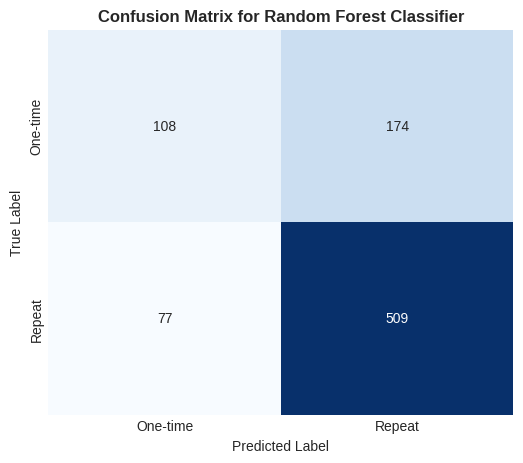

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['One-time', 'Repeat'],
            yticklabels=['One-time', 'Repeat'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Random Forest Classifier', fontweight='bold')
plt.show()

#### 📖 Reading the confusion matrix

The confusion matrix shows how the Random Forest performed on the test set (868 customers held back from training):

| | Predicted One-time | Predicted Repeat |
|---|---|---|
| **Actual One-time** | 108 ✓ | 174 ✗ |
| **Actual Repeat** | 77 ✗ | 509 ✓ |

**Overall accuracy: 71%** — (108 + 509) / 868

**The model is much better at finding repeat customers (87% recall) than one-time customers (38% recall).** It tends to predict Repeat when in doubt.

**Business interpretation:**
If Sarah used this model to identify customers for a retention campaign, roughly 1 in 4 contacts would be sent to customers who were never going to return — wasted spend, but not catastrophic given the low cost of email campaigns.

More importantly, the model misses 77 genuine repeat customers — predicting them as one-time. These are high-value customers the retention team would not contact. In business terms, **missing a loyal customer is a more costly error than incorrectly targeting a one-time buyer.** The model is acceptable for broad campaign targeting but should be supplemented with the RFM analysis above to protect the highest-value customers directly.

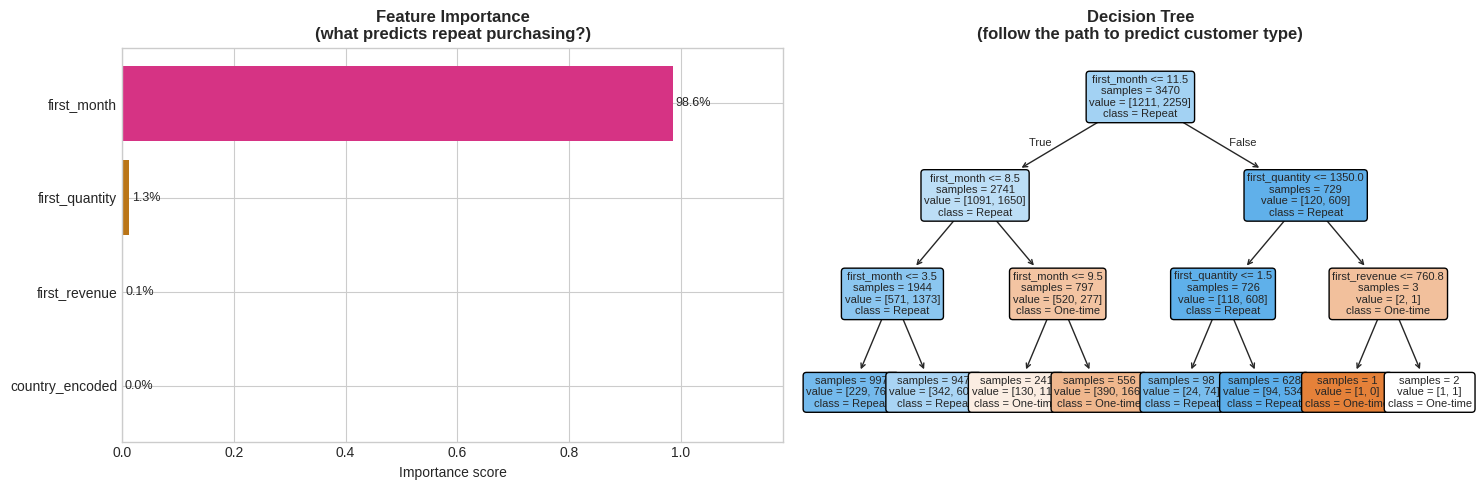

Feature importances:
        feature  importance
    first_month        0.99
 first_quantity        0.01
  first_revenue        0.00
country_encoded        0.00


In [ ]:
# Step 6: Feature importances — which factors matter most?
importances = pd.DataFrame({
    'feature':    features,
    'importance': tree.feature_importances_
}).sort_values('importance', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Feature importance bar chart
colours = ['#1D9E75','#534AB7','#BA7517','#d63384']
axes[0].barh(importances['feature'][::-1], importances['importance'][::-1],
             color=colours[:len(importances)])
axes[0].set_title('Feature Importance\n(what predicts repeat purchasing?)', fontweight='bold')
axes[0].set_xlabel('Importance score')
axes[0].set_xlim(0, importances['importance'].max() * 1.2)
for i, (_, row) in enumerate(importances.iloc[::-1].iterrows()):
    axes[0].text(row['importance'] + 0.005, i,
                 f'{row["importance"]*100:.1f}%', va='center', fontsize=9)

# Decision tree visualisation
plot_tree(tree,
          feature_names=features,
          class_names=['One-time','Repeat'],
          filled=True,
          rounded=True,
          ax=axes[1],
          fontsize=8,
          impurity=False)
axes[1].set_title('Decision Tree\n(follow the path to predict customer type)', fontweight='bold')

plt.tight_layout()
plt.show()

print('Feature importances:')
print(importances.to_string(index=False))

### Relationship between First Purchase Month and Repeat Rate

Repeat Rate by First Purchase Month:
 first_month  is_repeat  repeat_rate_pct
          12       0.84            83.70
           1       0.82            81.50
           2       0.77            77.10
           3       0.72            72.10
           5       0.69            69.40
           4       0.67            66.70
           6       0.64            64.50
           7       0.61            60.60
           8       0.54            54.40
           9       0.48            47.80
          10       0.35            34.60
          11       0.26            26.30


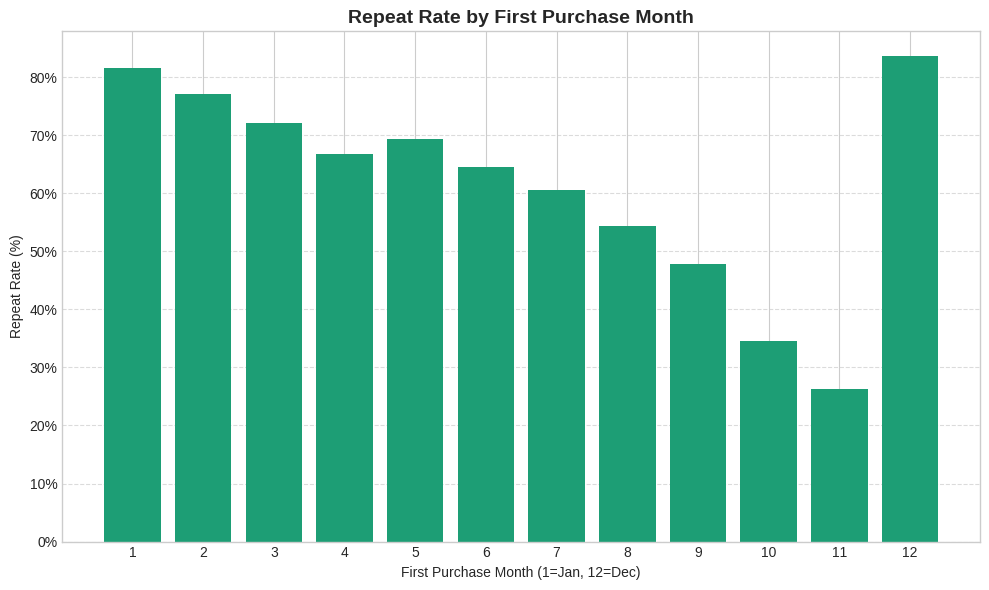

In [ ]:
# Let's analyse the direction for the most important feature: 'first_month'
# We'll calculate the repeat rate for each first_month

repeat_rate_by_month = model_df.groupby('first_month')['is_repeat'].mean().reset_index()
repeat_rate_by_month['repeat_rate_pct'] = (repeat_rate_by_month['is_repeat'] * 100).round(1)

print('Repeat Rate by First Purchase Month:')
print(repeat_rate_by_month.sort_values('repeat_rate_pct', ascending=False).to_string(index=False))

# Visualize the relationship
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(repeat_rate_by_month['first_month'], repeat_rate_by_month['repeat_rate_pct'], color='#1D9E75')
ax.set_title('Repeat Rate by First Purchase Month', fontweight='bold', fontsize=14)
ax.set_xlabel('First Purchase Month (1=Jan, 12=Dec)')
ax.set_ylabel('Repeat Rate (%)')
ax.set_xticks(range(1, 13))
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 📖 Reading the feature importance and decision tree

**Feature importance** shows that `first_month` (the month a customer first purchased) accounts for 98.6% of the model's decision — completely dominating all other features. First quantity contributes 1.3%, first revenue 0.1%, and country essentially nothing.

**Reading the decision tree:**
Each box contains: the question asked, the number of customers reaching that point, and the split between one-time [left] and repeat [right] in the value field. Blue boxes predict Repeat; orange boxes predict One-time.

Following the tree:
- **First split:** Was the first purchase before December? (month ≤ 11.5)
 - True → Jan–Nov customers (2,741): mostly repeat
 - False → December customers (729): 83% repeat — the strongest group
- **Second split for Jan–Nov:** Was it before September? (month ≤ 8.5)
 - True → Jan–Aug customers: reliably repeat (~71%)
 - False → Sep–Nov customers: majority one-time — the weakest group

**In plain English:**

| When they first bought | Repeat rate | What this suggests |
|---|---|---|
| December | 84% | Discovered brand at the most relevant moment — came back |
| January–August | ~70% | Organic discovery outside peak season — engaged buyers |
| September–November | Majority one-time | Pre-Christmas advertising traffic — bought once, did not return |

**Critical caution:**
The 98.6% dominance of `first_month` is a warning sign. When one feature dominates this completely it often indicates the model has found a data pattern rather than a true causal relationship. With only 13 months of data, acquisition month captures so much seasonal variation that it drowns out everything else. With multiple years of data, spend, product category, and country would likely emerge as meaningful predictors alongside timing. Treat these model results as directional, not definitive.

---
## 📖 Bringing it all together — Customer Analysis Summary

---

#### Finding

The EDA and model together reveal a consistent picture:
- Repeat customers outnumber one-time customers — the business has a stronger returning base than typical e-commerce benchmarks suggest
- Repeat customers generate a larger share of total revenue, driven by transaction frequency not higher spend per order — average order value is similar between the two groups
- The month of first purchase is the strongest predictor of whether a customer returns: December new customers return at 84%, September–November new customers mostly do not
- A subset of repeat customers has gone inactive (no purchase in 150+ days) and represents an immediate reactivation opportunity
- The Random Forest predicts repeat purchasing with 71% accuracy — sufficient for broad campaign targeting but not precision segmentation

---

#### Insight

**When a customer first discovers Festive & Co. matters more than how much they spend or where they live.** The business already has more repeat customers than one-time customers — which is a genuine strength. But this loyal base is currently invisible to the company: no loyalty programme, no differentiated treatment, and no early warning when a loyal customer goes quiet.

The company is also acquiring customers of very different quality throughout the year without measuring that difference. Pre-Christmas advertising brings in September–November first-timers who mostly buy once and disappear. Organic or word-of-mouth discovery brings in customers who tend to return. If marketing budget is allocated equally across the year, the ROI of different acquisition periods is invisible — and the September–November spend may be significantly less efficient than it appears.

---

#### Recommendation

**1. Protect the Champions.**
Identify the top customers by RFM score and treat them differently — early access to new products, personalised outreach before Christmas, a named contact for any service issues. Losing even a handful of Champions has an outsized revenue impact.

**2. Reactivate At Risk customers before the next gifting occasion.**
Customers who have not ordered in 90+ days but have a repeat history are the highest-priority marketing target. A personalised prompt — tied to Valentine's Day or Mother's Day — gives them a concrete reason to return at a natural gifting moment.

**3. Measure acquisition quality by month, not just volume.**
Track the 6-month repeat purchase rate for every new customer cohort. If September–November campaigns consistently produce one-time buyers, that acquisition cost should be evaluated differently from December campaigns that produce loyal customers. This analysis costs nothing to run and changes how marketing spend is allocated.

**4. Trigger a second-purchase campaign for December new customers.**
These customers have an 84% base rate of returning. A warm thank-you email 30 days after their first purchase — arriving in early January when post-Christmas sentiment is still positive — would convert a meaningful additional proportion at very low cost.

---
## ✏️ What's Next - Deepen your analysis after class

With these examples, you now have better ideas how to translate your data results into business insights and actionable recommendations. You can continue with further analysis from different angles in your spare time and train yourself how you should intepret your analysis results in a way business can take actions upon your recommendations.

Always remember:

data findings -> business insights -> recommendation